In [1]:
import sys

sys.path.append('../')

In [2]:
from PID_copy.PIDAttitudeAviary import PIDAttitudeAviary
from PID_copy.DSLPIDPolicy import DSLPIDPolicy
import numpy as np 
from ray.rllib.agents.ddpg.ddpg_torch_policy import DDPGTorchPolicy


In [3]:
from PID_copy.OffPolicyTrainer import OffPolicyTrainer

env_creator = lambda _: PIDAttitudeAviary()

trainer = OffPolicyTrainer(env_creator, 10000, 256, behavior_policy=DSLPIDPolicy, rl_policy=DDPGTorchPolicy)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


C:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))
2022-04-16 11:32:38,199	WARNING deprecation.py:45 -- DeprecationWarning: `convert_to_non_torch_type` has been deprecated. Use `ray/rllib/utils/numpy.py::convert_to_numpy` instead. This will raise an error in the future!


In [4]:
n_episodes = 1000
for i_eps in range(n_episodes):
    trainer.learn()
    if (i_eps%50) == 0:
        print("\rEpisode : ", i_eps, "Results : ", np.sum(trainer.evaluate()['rewards']))

C:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\ray\rllib\evaluation\collectors\simple_list_collector.py:35: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.array(v)


Episode :  0 Results :  -113.00064
Episode :  50 Results :  -222.51776
Episode :  100 Results :  -249.6082
Episode :  150 Results :  -199.04747
Episode :  200 Results :  -155.03432
Episode :  250 Results :  -221.69016
Episode :  300 Results :  -222.71136
Episode :  350 Results :  -229.25871
Episode :  400 Results :  -212.30145
Episode :  450 Results :  -244.97456
Episode :  500 Results :  -225.31146
Episode :  550 Results :  -243.9647
Episode :  600 Results :  -239.65878
Episode :  650 Results :  -214.89352
Episode :  700 Results :  -240.00272
Episode :  750 Results :  -222.2173
Episode :  800 Results :  -206.32971
Episode :  850 Results :  -221.5759
Episode :  900 Results :  -210.2415
Episode :  950 Results :  -209.40645


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


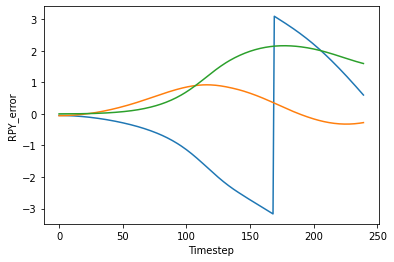

In [16]:
import time 
from gym_pybullet_drones.utils.utils import sync
import matplotlib.pyplot as plt 

env = PIDAttitudeAviary(gui=False)
# behavior_policy = DSLPIDPolicy(env.observation_space, env.action_space, config={})
policy = trainer.eval_worker.get_policy()

rpy_errs = []
cumm_reward = 0
obs = env.reset()
start = time.time()
for i in range(1*env.SIM_FREQ):
    action, _state, _dict = policy.compute_single_action(obs)
    obs, reward, done, info = env.step(action)
    cumm_reward += reward
    rpy_errs.append(info['rpy_err'])
    if env.GUI:
        if i%env.SIM_FREQ == 0:
            env.render()
            print(done)
        sync(i, start, env.TIMESTEP)
        if done:
            break

plt.plot(rpy_errs)
plt.xlabel("Timestep")
plt.ylabel("RPY_error")
plt.show()